# Sentiment Analysis of Customer Comments on Pakistani Fashion Brands

## Introduction
This notebook performs sentiment analysis on customer comments from social media platforms for Pakistani fashion brands such as Khaadi, Gul Ahmed, and Sapphire etc. It covers data preprocessing, sentiment analysis, and deriving insights, as required by the project specifications. All tools used are free and open-source to ensure accessibility.

## Setup
Install the necessary Python libraries. Run the following command in your environment if the libraries are not already installed:
```bash
pip install pandas nltk matplotlib seaborn wordcloud emoji
```


In [98]:
# Import libraries
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import emoji
from sklearn.feature_extraction.text import CountVectorizer

In [99]:
# Download necessary NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\alij7\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alij7\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [100]:
# Load the dataset
all_tweets = pd.read_csv("pakistani_fashion_comments.csv")

# Convert date column
all_tweets['date'] = pd.to_datetime(all_tweets['date'])
all_tweets.rename(columns={'comment':'text','date':'created_at'}, inplace=True)

In [101]:
all_tweets.head()

,brand,text,created_at,platform,language
0,J.,The Ramadan collection is breathtaking! Tradit...,2024-02-05,Facebook,English
1,Bonanza Satrangi,"Lahore store ka experience aam tha, na khas ac...",2024-02-21,Twitter,English
2,J.,New collection mein kuch interesting designs h...,2024-01-10,Twitter,English
3,Gul Ahmed,Finally a brand that understands hijab-friendl...,2024-03-13,Twitter,English
4,J.,Website crashed during sale and lost my cart i...,2024-02-15,Twitter,English


## Data Preprocessing
The collected data is cleaned to remove duplicates, URLs, mentions, hashtags, special characters, and stopwords to prepare it for sentiment analysis.

In [102]:
# English stopwords
eng_stops = set(stopwords.words('english'))
# simple Roman‑Urdu stopword list
roman_stops = {'hai','ka','ke','ko','mein','se','aur','yeh','woh','hayee','acha','bura','kya','hai','hai!'}
stop_words = eng_stops.union(roman_stops)

In [103]:
def clean_text(text):
    # strip URLs/mentions/hashtags
    text = re.sub(r'http\S+|@\w+|#\w+',' ', text)
    # remove emojis
    text = emoji.replace_emoji(text, replace='')
    # remove non‑letters
    text = re.sub(r'[^A-Za-z\s]', ' ', text).lower()
    # remove stopwords & extra spaces
    words = [w for w in text.split() if w not in stop_words and len(w)>1]
    return ' '.join(words)

In [104]:
all_tweets['clean_text'] = all_tweets['text'].apply(clean_text)

## Sentiment Analysis
We use VADER, a sentiment analysis tool optimized for social media text, to categorize posts as positive, negative, or neutral based on their polarity scores.

In [105]:
# Initialize VADER
sid = SentimentIntensityAnalyzer()

In [106]:
# Function to get sentiment
def get_sentiment(text):
    s = sid.polarity_scores(text)['compound']
    return 'positive' if s > 0.05 else ('negative' if s < -0.05 else 'neutral')

In [107]:
all_tweets['sentiment'] = all_tweets['clean_text'].map(get_sentiment)

### Visualize Sentiment Distribution
A bar chart shows the distribution of positive, negative, and neutral sentiments.

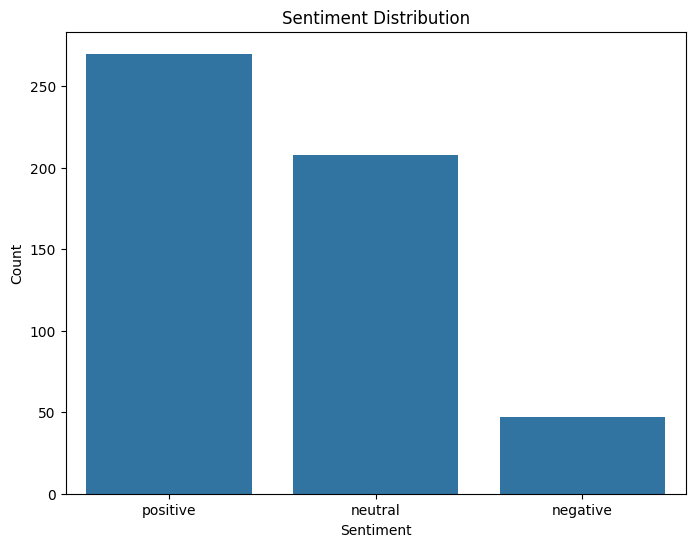

In [108]:
# Sentiment distribution
sentiment_counts = all_tweets['sentiment'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('sentiment_distribution.png')
plt.show()

### Visualize Sentiment Trends Over Time
A line graph illustrates how sentiments change over time, grouped by month.

In [109]:
# Convert created_at to datetime
all_tweets['created_at'] = pd.to_datetime(all_tweets['created_at'])
all_tweets['month'] = all_tweets['created_at'].dt.to_period('M')

In [110]:
# Group by month and sentiment
monthly_sentiment = all_tweets.groupby('month')['sentiment'].value_counts(normalize=True).unstack().fillna(0)

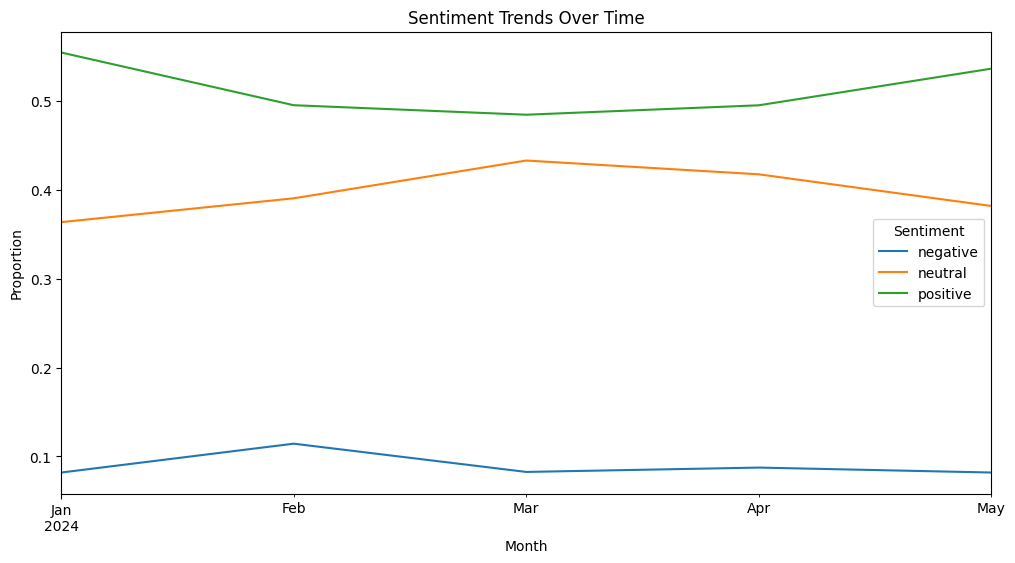

In [111]:
# Plot
monthly_sentiment.plot(kind='line', figsize=(12,6))
plt.title('Sentiment Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Proportion')
plt.legend(title='Sentiment')
plt.savefig('sentiment_trends.png')
plt.show()

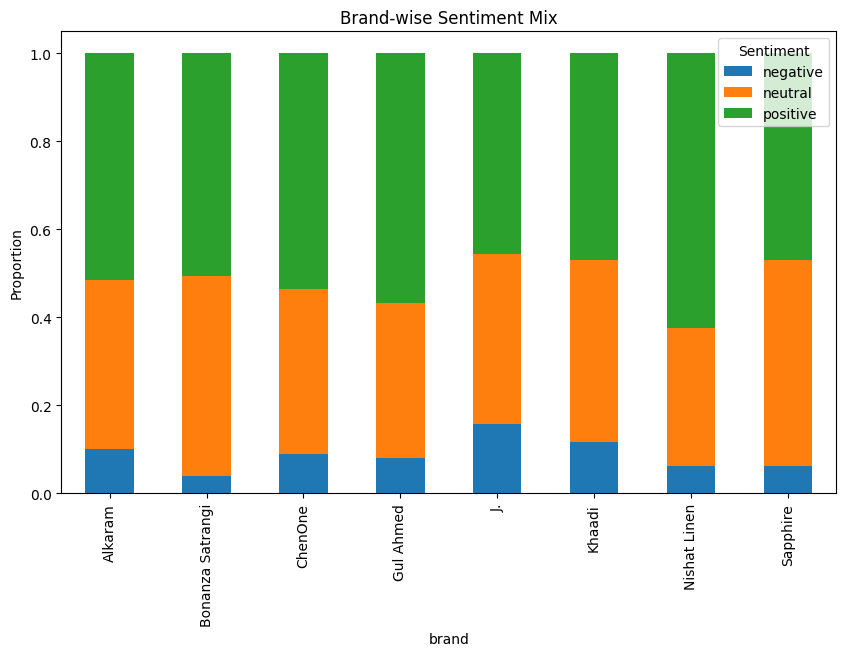

In [112]:
# Brand‑level sentiment proportions
brand_sent = all_tweets.groupby('brand')['sentiment'].value_counts(normalize=True).unstack().fillna(0)
brand_sent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Brand‑wise Sentiment Mix')
plt.ylabel('Proportion')
plt.legend(title='Sentiment')
plt.show()

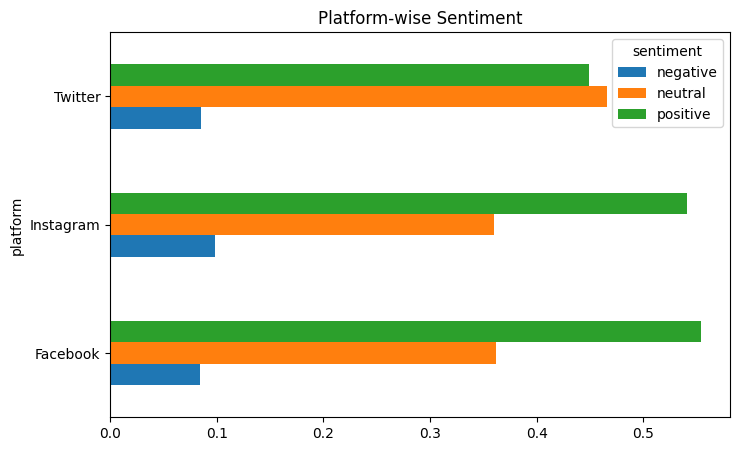

In [113]:
# Platform breakdown
plat_sent = all_tweets.groupby('platform')['sentiment'].value_counts(normalize=True).unstack().fillna(0)
plat_sent.plot(kind='barh', figsize=(8,5))
plt.title('Platform‑wise Sentiment')
plt.show()

### Keyword Analysis
We extract the most frequent words in positive and negative posts to understand what drives customer sentiment.

In [114]:
# Separate positive and negative posts
positive_tweets = all_tweets[all_tweets['sentiment'] == 'positive']['clean_text']
negative_tweets = all_tweets[all_tweets['sentiment'] == 'negative']['clean_text']

In [115]:
# Function to get top words
def get_top_words(texts, n=10):
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

In [116]:
# Get top words
top_positive_words = get_top_words(positive_tweets)
top_negative_words = get_top_words(negative_tweets)

In [117]:
print("Top positive words:", top_positive_words)
print("Top negative words:", top_negative_words)

Top positive words: [('collection', 59), ('friendly', 56), ('fashion', 56), ('perfect', 55), ('fabric', 54), ('new', 45), ('sustainable', 39), ('initiative', 39), ('eco', 39), ('packaging', 39)]
Top negative words: [('quality', 12), ('website', 11), ('sale', 11), ('cart', 11), ('time', 10), ('order', 7), ('delayed', 7), ('weeks', 7), ('communication', 7), ('unacceptable', 7)]


In [118]:
# Top bigrams in negative vs positive
def top_ngrams(corpus, ngram_range=(2,2), top_n=10):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag = vec.transform(corpus)
    sums = bag.sum(axis=0)
    freqs = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(freqs, key=lambda x: -x[1])[:top_n]

In [119]:
print("Top positive bigrams:", top_ngrams(all_tweets[all_tweets.sentiment=='positive']['clean_text']))
print("Top negative bigrams:", top_ngrams(all_tweets[all_tweets.sentiment=='negative']['clean_text']))

Top positive bigrams: [('sustainable fashion', np.int64(39)), ('fashion initiative', np.int64(39)), ('eco friendly', np.int64(39)), ('friendly packaging', np.int64(39)), ('fabric quality', np.int64(33)), ('absolutely love', np.int64(30)), ('love new', np.int64(30)), ('new lawn', np.int64(30)), ('lawn collection', np.int64(30)), ('customer service', np.int64(29))]
Top negative bigrams: [('order delayed', np.int64(7)), ('delayed weeks', np.int64(7)), ('weeks communication', np.int64(7)), ('communication unacceptable', np.int64(7)), ('colors faded', np.int64(7)), ('faded first', np.int64(7)), ('first wash', np.int64(7)), ('wash poor', np.int64(7)), ('poor quality', np.int64(7)), ('quality control', np.int64(7))]


### Word Clouds
Word clouds provide a visual representation of frequent terms in positive and negative posts.

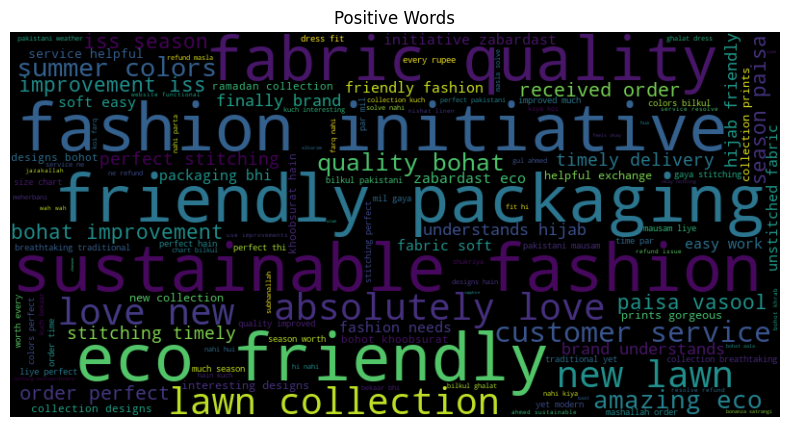

In [120]:
# Positive word cloud
positive_wordcloud = WordCloud(width=800, height=400).generate(' '.join(positive_tweets))
plt.figure(figsize=(10,5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Words')
plt.axis('off')
plt.savefig('positive_wordcloud.png')
plt.show()

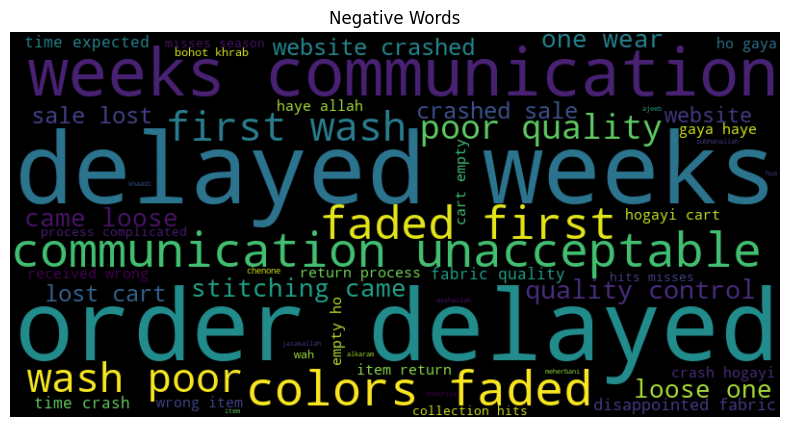

In [121]:
# Negative word cloud
negative_wordcloud = WordCloud(width=800, height=400).generate(' '.join(negative_tweets))
plt.figure(figsize=(10,5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Words')
plt.axis('off')
plt.savefig('negative_wordcloud.png')
plt.show()

## Conclusion
This notebook fulfills the project requirements by collecting and analyzing customer comments from social media platforms, providing insights into sentiment drivers and temporal trends. Users can extend the analysis by adjusting the number of posts collected, including additional brands, or specifying event dates for deeper temporal analysis.

### Deliverables
The following files are generated:
- `pakistani_fashion_comments.csv`: The dataset.
- `sentiment_distribution.png`: Bar chart of sentiment distribution.
- `sentiment_trends.png`: Line graph of sentiment trends.
- `positive_wordcloud.png`: Word cloud for positive posts.
- `negative_wordcloud.png`: Word cloud for negative posts.